# Regression Plot Comparison

Compare regression predictions across multiple checkpoints and render a publication-friendly multi-panel figure.


## 1) Setup


In [1]:
import os
import sys
import math
import pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
from matplotlib.lines import Line2D
from matplotlib.patches import Patch


def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, cwd.parent):
        if (candidate / 'src').exists():
            return candidate
    raise FileNotFoundError("Cannot find project root containing 'src' directory.")


PROJECT_ROOT = resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

FIG_DIR = PROJECT_ROOT / 'notebooks' / 'figs'
CACHE_DIR = PROJECT_ROOT / 'notebooks' / 'figs_data'
FIG_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

print(f'PROJECT_ROOT: {PROJECT_ROOT}')
print(f'DEVICE: {DEVICE}')


PROJECT_ROOT: /root/autodl-tmp/em_eqf
DEVICE: cuda:0


## 2) Plot Utility


In [2]:
def canonical_split_name(name: str) -> str:
    key = str(name).strip().lower()
    mapping = {
        'train': 'Train',
        'tr': 'Train',
        'val': 'Validation',
        'valid': 'Validation',
        'validation': 'Validation',
        'test': 'Test',
        'te': 'Test',
    }
    return mapping.get(key, str(name))


def ordered_segments(data_dict, split_order=('Train', 'Validation', 'Test')):
    normalized = []
    for label, (true_vals, pred_vals) in data_dict.items():
        normalized.append((canonical_split_name(label), np.asarray(true_vals), np.asarray(pred_vals)))

    ordered = []
    for split in split_order:
        ordered.extend([item for item in normalized if item[0] == split])
    ordered.extend([item for item in normalized if item[0] not in split_order])
    return ordered


def _panel_label_from_index(i: int) -> str:
    n = i + 1
    chars = []
    while n > 0:
        n, rem = divmod(n - 1, 26)
        chars.append(chr(ord('a') + rem))
    return f"({''.join(reversed(chars))})"


def plot_multiple_regression_series(
    data_dicts,
    titles=None,
    save_path=None,
    verbose=False,
    cols=2,
    figsize_per_col=6.4,
    figsize_per_row=3.8,
    linewidth=1.8,
    pred_linestyle='--',
    true_color='k',
    pred_color='tab:orange',
    split_order=('Train', 'Validation', 'Test'),
    split_facecolors=None,
    alpha_span=0.10,
    unify_ylim=True,
    ylim_pad=0.15,
    fontsize=10,
    title_fontsize=11,
    panel_label_fontsize=11,
    ncol_legend=4,
    show=True,
):
    if split_facecolors is None:
        split_facecolors = {
            'Train': 'tab:green',
            'Validation': 'tab:blue',
            'Test': 'tab:purple',
        }

    if len(data_dicts) == 0:
        raise ValueError('data_dicts is empty.')

    n = len(data_dicts)
    cols = min(cols, n)
    rows = math.ceil(n / cols)

    fig, axs = plt.subplots(rows, cols, figsize=(figsize_per_col * cols, figsize_per_row * rows), squeeze=False)
    axs = axs.reshape(-1)

    global_min, global_max = np.inf, -np.inf
    if unify_ylim:
        for dd in data_dicts:
            for _, y_true, y_pred in ordered_segments(dd, split_order=split_order):
                if y_true.size:
                    global_min = min(global_min, np.nanmin(y_true), np.nanmin(y_pred))
                    global_max = max(global_max, np.nanmax(y_true), np.nanmax(y_pred))
        if not np.isfinite(global_min) or not np.isfinite(global_max):
            global_min, global_max = 0.0, 1.0
        pad = (global_max - global_min) * ylim_pad if global_max > global_min else 0.5
        y_lim = (global_min - pad, global_max + pad)
    else:
        y_lim = None

    for i, (ax, data_dict) in enumerate(zip(axs, data_dicts)):
        segments = ordered_segments(data_dict, split_order=split_order)
        cursor = 0

        for split_name, y_true, y_pred in segments:
            n_seg = len(y_true)
            if n_seg == 0:
                continue
            x = np.arange(cursor, cursor + n_seg)

            ax.axvspan(x[0], x[-1], color=split_facecolors.get(split_name, 'lightgray'), alpha=alpha_span, lw=0)
            ax.plot(x, y_true, color=true_color, lw=linewidth, label='True' if cursor == 0 else None)
            ax.plot(x, y_pred, color=pred_color, lw=linewidth, ls=pred_linestyle, label='Pred' if cursor == 0 else None)

            cursor += n_seg

        ax.set_title((titles[i] if titles and i < len(titles) else f'Model {i+1}'), fontsize=title_fontsize)
        ax.text(0.01, 0.99, _panel_label_from_index(i), transform=ax.transAxes, va='top', ha='left', fontsize=panel_label_fontsize)
        ax.grid(alpha=0.25)
        ax.tick_params(labelsize=fontsize)
        if y_lim is not None:
            ax.set_ylim(*y_lim)

    for j in range(n, len(axs)):
        axs[j].axis('off')

    split_handles = [
        Patch(facecolor=split_facecolors[k], alpha=alpha_span, label=k)
        for k in split_order if k in split_facecolors
    ]
    line_handles = [
        Line2D([0], [0], color=true_color, lw=linewidth, label='True'),
        Line2D([0], [0], color=pred_color, lw=linewidth, ls=pred_linestyle, label='Pred'),
    ]
    fig.legend(handles=line_handles + split_handles, loc='lower center', ncol=ncol_legend, frameon=False)

    fig.tight_layout(rect=[0, 0.05, 1, 1])

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
        if verbose:
            print(f'Saved plot to: {save_path}')

    if show:
        plt.show()
    else:
        plt.close(fig)


## 3) Build `data_dicts` From Checkpoints


In [3]:
from src.train.config_setup import load_and_prepare_model
from src.data.preparation import prepare_data, prepare_data_lstm
from src.train.regressor_train_step import get_data_dict


def get_data_dicts_from_checkpoints(experiments, device):
    data_dicts = []
    titles = []
    loader_cache = {}

    for exp in experiments:
        checkpoint_path = Path(exp['checkpoint'])
        if not checkpoint_path.exists():
            raise FileNotFoundError(f'Checkpoint not found: {checkpoint_path}')

        model, args = load_and_prepare_model(
            checkpoint_path=checkpoint_path,
            device=device,
            compile=False,
        )

        prepare_fn = exp['prepare_fn']
        cache_key = (prepare_fn.__name__, args.dataset)

        if cache_key not in loader_cache:
            _, train_loader, val_loader, test_loader, _ = prepare_fn(
                base_dir=str(PROJECT_ROOT / 'data' / args.dataset),
                args=args,
            )
            loader_cache[cache_key] = (train_loader, val_loader, test_loader)

        train_loader, val_loader, test_loader = loader_cache[cache_key]
        data_dict = get_data_dict([train_loader, val_loader, test_loader], model, device)

        data_dicts.append(data_dict)
        titles.append(exp['title'])

        del model
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    return data_dicts, titles


## 4) Experiment Config and Cache


In [8]:
EXPERIMENTS = [
    {
        'title': 'EM-EQF',
        'checkpoint': PROJECT_ROOT / 'experiments/reg_mixer_attnpl_a/runs/reg_ab_reg_seed_1' / 'last_model_1.pth',
        'prepare_fn': prepare_data,
    },
    {
        'title': r'EM-EQF (+$\log(\Delta t)$)',
        'checkpoint': PROJECT_ROOT / 'experiments/reg_mixer_attnpl_a/runs/reg_ab_log_pretrain_seed_1' / 'last_model_1.pth',
        'prepare_fn': prepare_data,
    },
    {
        'title': 'EM-EQF (-T-XPOS)',
        'checkpoint': PROJECT_ROOT / 'experiments/reg_mixer_attnpl_a/runs/reg_ab_minus_txpos_seed_1' / 'last_model_1.pth',
        'prepare_fn': prepare_data,
    },
    {
        'title': 'EM-EQF (-TMAP)',
        'checkpoint': PROJECT_ROOT / 'experiments/reg_mixer_attnpl_a/runs/reg_ab_minus_tmap_seed_1' / 'last_model_1.pth',
        'prepare_fn': prepare_data,
    },
    {
        'title': 'EM-EQF (-Pretrain)',
        'checkpoint': PROJECT_ROOT / 'experiments/reg_mixer_attnpl_a/runs/reg_ab_log_pretrain_seed_1' / 'last_model_1.pth',
        'prepare_fn': prepare_data,
    },
]

CACHE_PATH = CACHE_DIR / 'reg_data_dicts.pkl'
USE_CACHE = False
SAVE_CACHE = False

if USE_CACHE and CACHE_PATH.exists():
    with open(CACHE_PATH, 'rb') as f:
        cached = pickle.load(f)

    if isinstance(cached, dict):
        data_dicts = cached['data_dicts']
        titles = cached.get('titles', [exp['title'] for exp in EXPERIMENTS])
    else:
        data_dicts = cached
        titles = [exp['title'] for exp in EXPERIMENTS][:len(data_dicts)]

    print(f'Loaded cached data_dicts from: {CACHE_PATH}')
else:
    data_dicts, titles = get_data_dicts_from_checkpoints(EXPERIMENTS, DEVICE)

    if SAVE_CACHE:
        with open(CACHE_PATH, 'wb') as f:
            pickle.dump({'data_dicts': data_dicts, 'titles': titles}, f)
        print(f'Saved data_dicts to: {CACHE_PATH}')

print(f'Number of experiments: {len(data_dicts)}')
print(f'Titles: {titles}')


Number of experiments: 5
Titles: ['EM-EQF', 'EM-EQF (+$\\log(\\Delta t)$)', 'EM-EQF (-T-XPOS)', 'EM-EQF (-TMAP)', 'EM-EQF (-Pretrain)']


## 5) Plot


Saved plot to: /root/autodl-tmp/em_eqf/notebooks/figs/regression_plots.pdf


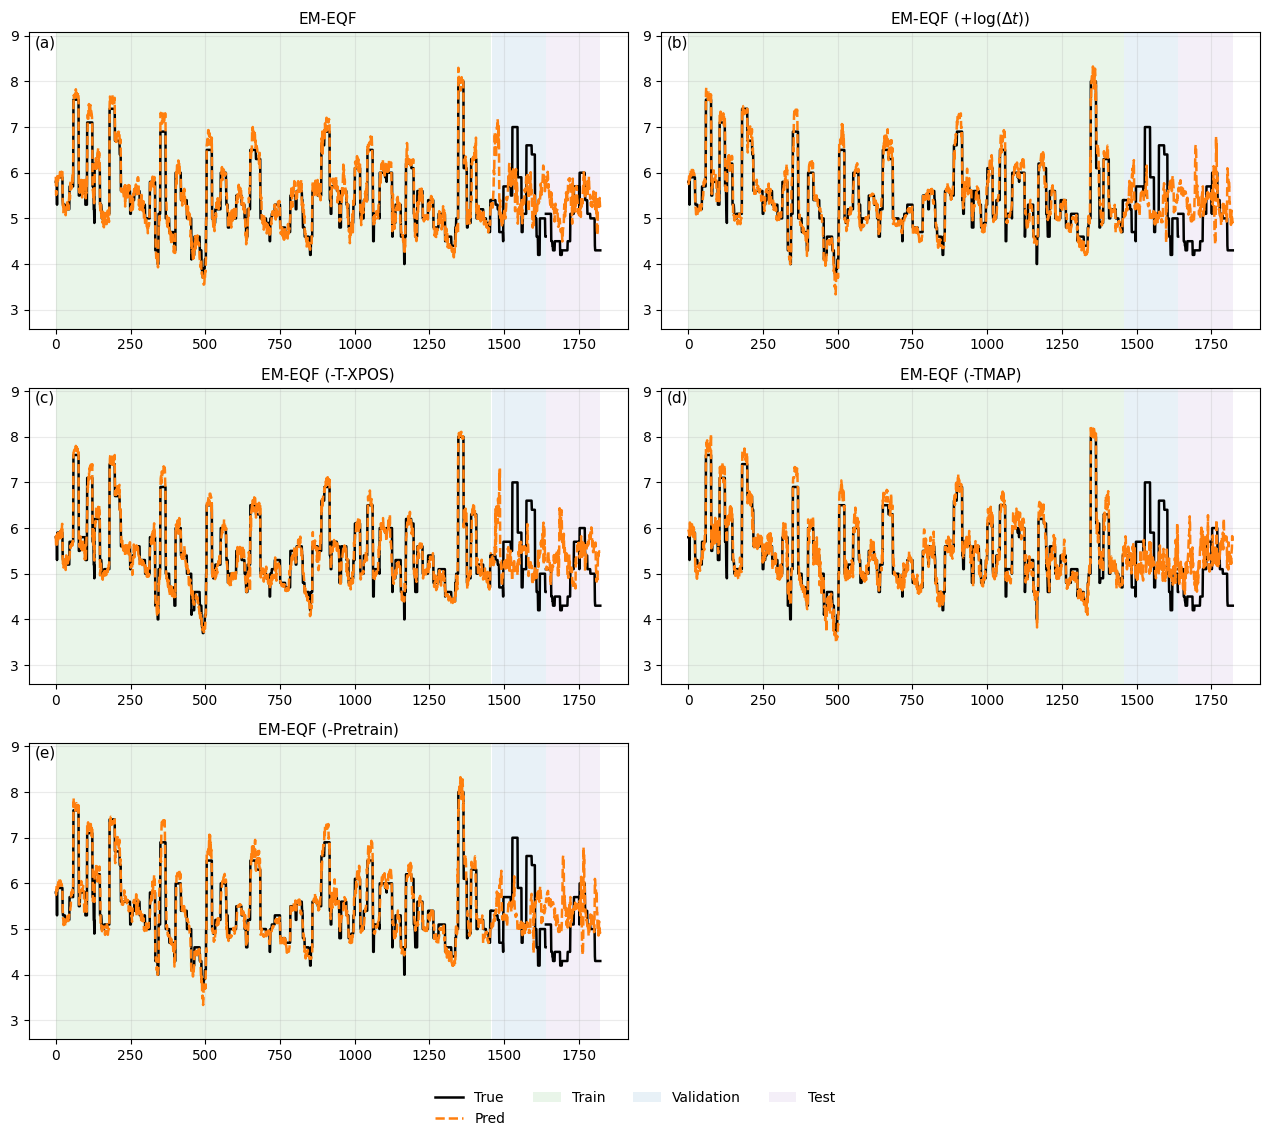

In [9]:
OUTPUT_PATH = FIG_DIR / 'regression_plots.pdf'

plot_multiple_regression_series(
    data_dicts=data_dicts,
    titles=titles,
    save_path=str(OUTPUT_PATH),
    verbose=True,
)


## 6) Bootstrap Metrics and Export

Compute bootstrap confidence intervals (paired block bootstrap on Test split) and support CSV/JSON export.


In [10]:
import pandas as pd
from src.utils.bootstrap_ci import BootstrapConfig, bootstrap_multi_model_metric_ci

BOOTSTRAP_METRICS = ('rmse', 'mae', 'r2', 'mse')
BOOTSTRAP_SPLIT_ORDER = ('Test',)
BOOTSTRAP_MODE = 'paired_block'
BOOTSTRAP_BASELINE_MODEL = 'EM-EQF'  # None => use the first title in `titles` as baseline
BOOTSTRAP_CONFIG = BootstrapConfig(
    n_resamples=1000,
    ci=(2.5, 97.5),
    seed=42,
    sampling='block',
    block_size=4 ,
    circular_block=True,
)


def _collect_regression_split_payload(data_dicts, titles, split_order):
    split_payload = {}
    for model_title, data_dict in zip(titles, data_dicts):
        for raw_split_name, (y_true_raw, y_pred_raw) in data_dict.items():
            split_name = canonical_split_name(raw_split_name)
            if split_name not in split_order:
                continue
            y_true = np.asarray(y_true_raw).reshape(-1)
            y_pred = np.asarray(y_pred_raw).reshape(-1)

            if y_true.shape[0] != y_pred.shape[0]:
                raise ValueError(f'Length mismatch in {model_title}/{split_name}: y_true={y_true.shape[0]}, y_pred={y_pred.shape[0]}')

            payload = split_payload.setdefault(split_name, {'y_true': None, 'model_predictions': {}})
            if payload['y_true'] is None:
                payload['y_true'] = y_true
            else:
                ref = payload['y_true']
                if ref.shape[0] != y_true.shape[0] or not np.allclose(ref, y_true, rtol=1e-6, atol=1e-8):
                    raise ValueError(
                        f'y_true mismatch across models for split={split_name}. '
                        f'Expected aligned samples for paired bootstrap.'
                    )

            payload['model_predictions'][model_title] = y_pred

    return split_payload


def compute_regression_paired_block_bootstrap_tables(
    data_dicts,
    titles,
    metrics=BOOTSTRAP_METRICS,
    config=BOOTSTRAP_CONFIG,
    split_order=BOOTSTRAP_SPLIT_ORDER,
    baseline_model=None,
):
    split_payload = _collect_regression_split_payload(data_dicts, titles, split_order)

    ordered_splits = [s for s in split_order if s in split_payload]

    effective_baseline_model = baseline_model or (titles[0] if len(titles) > 0 else None)
    if effective_baseline_model is None:
        raise ValueError('No models found; cannot determine baseline model.')

    model_rows = []
    delta_rows = []

    for split_name in ordered_splits:
        payload = split_payload[split_name]
        y_true = payload['y_true']
        model_predictions = payload['model_predictions']

        for metric_name in metrics:
            result = bootstrap_multi_model_metric_ci(
                y_true=y_true,
                model_predictions=model_predictions,
                metric=metric_name,
                task='regression',
                config=config,
                baseline_model=effective_baseline_model,
            )

            for model_name, boot in result.model_results.items():
                model_rows.append({
                    'mode': BOOTSTRAP_MODE,
                    'baseline_model': effective_baseline_model,
                    'model': model_name,
                    'split': split_name,
                    'metric': metric_name,
                    'n_obs': int(y_true.size),
                    'point_estimate': float(boot.point_estimate),
                    'ci_low': float(boot.ci_low),
                    'ci_high': float(boot.ci_high),
                    'valid_resamples': int(boot.valid_resamples),
                    'total_resamples': int(boot.total_resamples),
                })

            for (left_model, right_model), delta in result.pairwise_deltas.items():
                delta_rows.append({
                    'mode': BOOTSTRAP_MODE,
                    'baseline_model': effective_baseline_model,
                    'split': split_name,
                    'metric': metric_name,
                    'left_model': left_model,
                    'right_model': right_model,
                    'delta_name': f'{left_model} - {right_model}',
                    'point_estimate': float(delta.point_estimate),
                    'ci_low': float(delta.ci_low),
                    'ci_high': float(delta.ci_high),
                    'valid_resamples': int(delta.valid_resamples),
                    'total_resamples': int(delta.total_resamples),
                })

    model_df = pd.DataFrame(model_rows)
    if not model_df.empty:
        model_df['ci_95'] = model_df.apply(lambda r: f"[{r['ci_low']:.4f}, {r['ci_high']:.4f}]", axis=1)

    delta_df = pd.DataFrame(delta_rows)
    if not delta_df.empty:
        delta_df['ci_95'] = delta_df.apply(lambda r: f"[{r['ci_low']:.4f}, {r['ci_high']:.4f}]", axis=1)

    return model_df, delta_df


effective_baseline_model = BOOTSTRAP_BASELINE_MODEL or (titles[0] if len(titles) > 0 else None)
if effective_baseline_model is None:
    raise ValueError('No models found; cannot determine baseline model.')

bootstrap_metrics_df, bootstrap_pairwise_delta_df = compute_regression_paired_block_bootstrap_tables(
    data_dicts=data_dicts,
    titles=titles,
    baseline_model=effective_baseline_model,
)

bootstrap_metrics_wide_df = (
    bootstrap_metrics_df
    .assign(
        point_ci=lambda d: d.apply(
            lambda r: f"{r['point_estimate']:.4f} [{r['ci_low']:.4f}, {r['ci_high']:.4f}]", axis=1
        )
    )
    .pivot(index=['split', 'metric'], columns='model', values='point_ci')
    .reset_index()
)

print(f'Bootstrap mode: {BOOTSTRAP_MODE}')
print(f'Bootstrap baseline model: {effective_baseline_model}')
print(f'Bootstrap config: {BOOTSTRAP_CONFIG}')
display(bootstrap_metrics_df)
display(bootstrap_metrics_wide_df)
display(bootstrap_pairwise_delta_df)



Bootstrap mode: paired_block
Bootstrap baseline model: EM-EQF
Bootstrap config: BootstrapConfig(n_resamples=1000, ci=(2.5, 97.5), seed=42, sampling='block', block_size=4, circular_block=True)


,mode,baseline_model,model,split,metric,n_obs,point_estimate,ci_low,ci_high,valid_resamples,total_resamples,ci_95
0,paired_block,EM-EQF,EM-EQF,Test,rmse,183,0.697120,0.607740,0.783705,1000,1000,"[0.6077, 0.7837]"
1,paired_block,EM-EQF,EM-EQF (+$\log(\Delta t)$),Test,rmse,183,0.811965,0.657821,0.968295,1000,1000,"[0.6578, 0.9683]"
2,paired_block,EM-EQF,EM-EQF (-T-XPOS),Test,rmse,183,0.826161,0.694769,0.957587,1000,1000,"[0.6948, 0.9576]"
3,paired_block,EM-EQF,EM-EQF (-TMAP),Test,rmse,183,0.753158,0.652916,0.850917,1000,1000,"[0.6529, 0.8509]"
4,paired_block,EM-EQF,EM-EQF (-Pretrain),Test,rmse,183,0.811965,0.657821,0.968295,1000,1000,"[0.6578, 0.9683]"
5,paired_block,EM-EQF,EM-EQF,Test,mae,183,0.611578,0.523520,0.699536,1000,1000,"[0.5235, 0.6995]"
6,paired_block,EM-EQF,EM-EQF (+$\log(\Delta t)$),Test,mae,183,0.649466,0.517765,0.792402,1000,1000,"[0.5178, 0.7924]"
7,paired_block,EM-EQF,EM-EQF (-T-XPOS),Test,mae,183,0.685789,0.565637,0.809618,1000,1000,"[0.5656, 0.8096]"
8,paired_block,EM-EQF,EM-EQF (-TMAP),Test,mae,183,0.642286,0.544244,0.741570,1000,1000,"[0.5442, 0.7416]"
9,paired_block,EM-EQF,EM-EQF (-Pretrain),Test,mae,183,0.649466,0.517765,0.792402,1000,1000,"[0.5178, 0.7924]"


model,split,metric,EM-EQF,EM-EQF (+$\log(\Delta t)$),EM-EQF (-Pretrain),EM-EQF (-T-XPOS),EM-EQF (-TMAP)
0,Test,mae,"0.6116 [0.5235, 0.6995]","0.6495 [0.5178, 0.7924]","0.6495 [0.5178, 0.7924]","0.6858 [0.5656, 0.8096]","0.6423 [0.5442, 0.7416]"
1,Test,mse,"0.4860 [0.3693, 0.6142]","0.6593 [0.4327, 0.9376]","0.6593 [0.4327, 0.9376]","0.6825 [0.4827, 0.9170]","0.5672 [0.4263, 0.7241]"
2,Test,r2,"-0.4523 [-1.2264, -0.0240]","-0.9702 [-2.1547, -0.3222]","-0.9702 [-2.1547, -0.3222]","-1.0397 [-2.2142, -0.3948]","-0.6951 [-1.6017, -0.1684]"
3,Test,rmse,"0.6971 [0.6077, 0.7837]","0.8120 [0.6578, 0.9683]","0.8120 [0.6578, 0.9683]","0.8262 [0.6948, 0.9576]","0.7532 [0.6529, 0.8509]"


,mode,baseline_model,split,metric,left_model,right_model,delta_name,point_estimate,ci_low,ci_high,valid_resamples,total_resamples,ci_95
0,paired_block,EM-EQF,Test,rmse,EM-EQF (+$\log(\Delta t)$),EM-EQF,EM-EQF (+$\log(\Delta t)$) - EM-EQF,0.114845,-0.033695,0.274653,1000,1000,"[-0.0337, 0.2747]"
1,paired_block,EM-EQF,Test,rmse,EM-EQF (-T-XPOS),EM-EQF,EM-EQF (-T-XPOS) - EM-EQF,0.129040,-0.013168,0.290913,1000,1000,"[-0.0132, 0.2909]"
2,paired_block,EM-EQF,Test,rmse,EM-EQF (-TMAP),EM-EQF,EM-EQF (-TMAP) - EM-EQF,0.056037,-0.028589,0.152422,1000,1000,"[-0.0286, 0.1524]"
3,paired_block,EM-EQF,Test,rmse,EM-EQF (-Pretrain),EM-EQF,EM-EQF (-Pretrain) - EM-EQF,0.114845,-0.033695,0.274653,1000,1000,"[-0.0337, 0.2747]"
4,paired_block,EM-EQF,Test,mae,EM-EQF (+$\log(\Delta t)$),EM-EQF,EM-EQF (+$\log(\Delta t)$) - EM-EQF,0.037888,-0.078392,0.174183,1000,1000,"[-0.0784, 0.1742]"
5,paired_block,EM-EQF,Test,mae,EM-EQF (-T-XPOS),EM-EQF,EM-EQF (-T-XPOS) - EM-EQF,0.074211,-0.050647,0.207755,1000,1000,"[-0.0506, 0.2078]"
6,paired_block,EM-EQF,Test,mae,EM-EQF (-TMAP),EM-EQF,EM-EQF (-TMAP) - EM-EQF,0.030708,-0.060612,0.124862,1000,1000,"[-0.0606, 0.1249]"
7,paired_block,EM-EQF,Test,mae,EM-EQF (-Pretrain),EM-EQF,EM-EQF (-Pretrain) - EM-EQF,0.037888,-0.078392,0.174183,1000,1000,"[-0.0784, 0.1742]"
8,paired_block,EM-EQF,Test,r2,EM-EQF (+$\log(\Delta t)$),EM-EQF,EM-EQF (+$\log(\Delta t)$) - EM-EQF,-0.517909,-1.400749,0.176296,1000,1000,"[-1.4007, 0.1763]"
9,paired_block,EM-EQF,Test,r2,EM-EQF (-T-XPOS),EM-EQF,EM-EQF (-T-XPOS) - EM-EQF,-0.587401,-1.476050,0.058222,1000,1000,"[-1.4760, 0.0582]"


In [11]:
EXPORT_BOOTSTRAP = True
BOOTSTRAP_EXPORT_DIR = PROJECT_ROOT / 'notebooks' / 'metrics' / 'regression_comparison'
BOOTSTRAP_EXPORT_DIR.mkdir(parents=True, exist_ok=True)
BOOTSTRAP_EXPORT_STEM = f'regression_comparison_bootstrap_metrics_{BOOTSTRAP_MODE}'

if EXPORT_BOOTSTRAP:
    ts = pd.Timestamp.now().strftime('%Y%m%d_%H%M%S')

    long_csv_path = BOOTSTRAP_EXPORT_DIR / f'{BOOTSTRAP_EXPORT_STEM}_long_{ts}.csv'
    wide_csv_path = BOOTSTRAP_EXPORT_DIR / f'{BOOTSTRAP_EXPORT_STEM}_wide_{ts}.csv'
    pair_delta_csv_path = BOOTSTRAP_EXPORT_DIR / f'{BOOTSTRAP_EXPORT_STEM}_pairwise_delta_{ts}.csv'
    json_path = BOOTSTRAP_EXPORT_DIR / f'{BOOTSTRAP_EXPORT_STEM}_long_{ts}.json'
    pair_delta_json_path = BOOTSTRAP_EXPORT_DIR / f'{BOOTSTRAP_EXPORT_STEM}_pairwise_delta_{ts}.json'

    bootstrap_metrics_df.to_csv(long_csv_path, index=False)
    bootstrap_metrics_wide_df.to_csv(wide_csv_path, index=False)
    bootstrap_pairwise_delta_df.to_csv(pair_delta_csv_path, index=False)
    bootstrap_metrics_df.to_json(json_path, orient='records', force_ascii=False, indent=2)
    bootstrap_pairwise_delta_df.to_json(pair_delta_json_path, orient='records', force_ascii=False, indent=2)

    print(f'Bootstrap long CSV exported: {long_csv_path}')
    print(f'Bootstrap wide CSV exported: {wide_csv_path}')
    print(f'Bootstrap pairwise delta CSV exported: {pair_delta_csv_path}')
    print(f'Bootstrap JSON exported: {json_path}')
    print(f'Bootstrap pairwise delta JSON exported: {pair_delta_json_path}')
else:
    print('EXPORT_BOOTSTRAP=False, skip export.')


Bootstrap long CSV exported: /root/autodl-tmp/em_eqf/notebooks/metrics/regression_comparison/regression_comparison_bootstrap_metrics_paired_block_long_20260515_233336.csv
Bootstrap wide CSV exported: /root/autodl-tmp/em_eqf/notebooks/metrics/regression_comparison/regression_comparison_bootstrap_metrics_paired_block_wide_20260515_233336.csv
Bootstrap pairwise delta CSV exported: /root/autodl-tmp/em_eqf/notebooks/metrics/regression_comparison/regression_comparison_bootstrap_metrics_paired_block_pairwise_delta_20260515_233336.csv
Bootstrap JSON exported: /root/autodl-tmp/em_eqf/notebooks/metrics/regression_comparison/regression_comparison_bootstrap_metrics_paired_block_long_20260515_233336.json
Bootstrap pairwise delta JSON exported: /root/autodl-tmp/em_eqf/notebooks/metrics/regression_comparison/regression_comparison_bootstrap_metrics_paired_block_pairwise_delta_20260515_233336.json
